In [4]:
import imfusion as imf
from imfusion import vision
import numpy as np
from matplotlib import pyplot as plt
import pathlib
import cv2


## a. Load input data
The input data is a pair of images of a scene taken from different viewpoints. The images are stored in an ImFusion file.

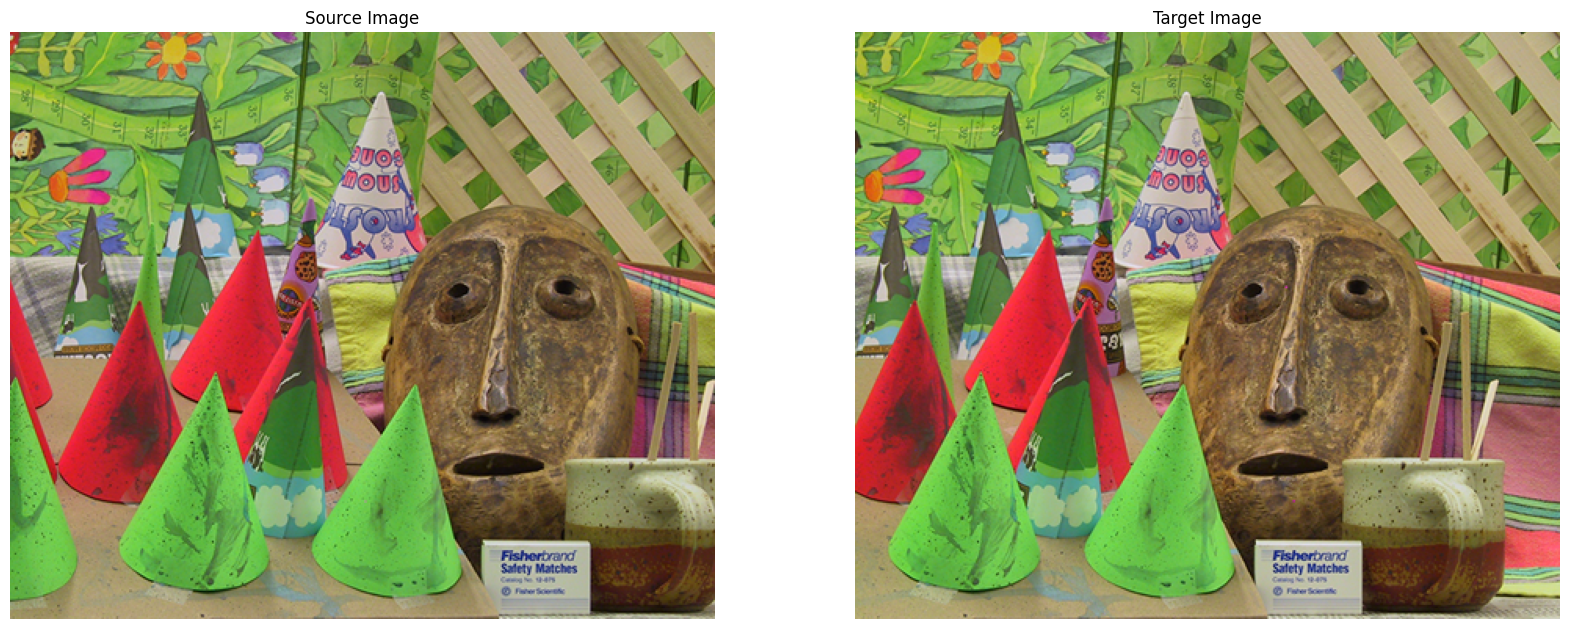

In [2]:
images, *_ = imf.load("./data/feature_matching.imf")
plt.figure(figsize=(20,10))
plt.subplot(1,2,1)
plt.imshow(np.array(images[0]))
plt.title("Source Image")
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(np.array(images[1]))
plt.title("Target Image")
plt.axis('off')
plt.show()

## b. Detection and Matching
Extract features on detected keypoints and match the descriptors between the two images. Here we use a additional a GMS pruner to filter the matches.

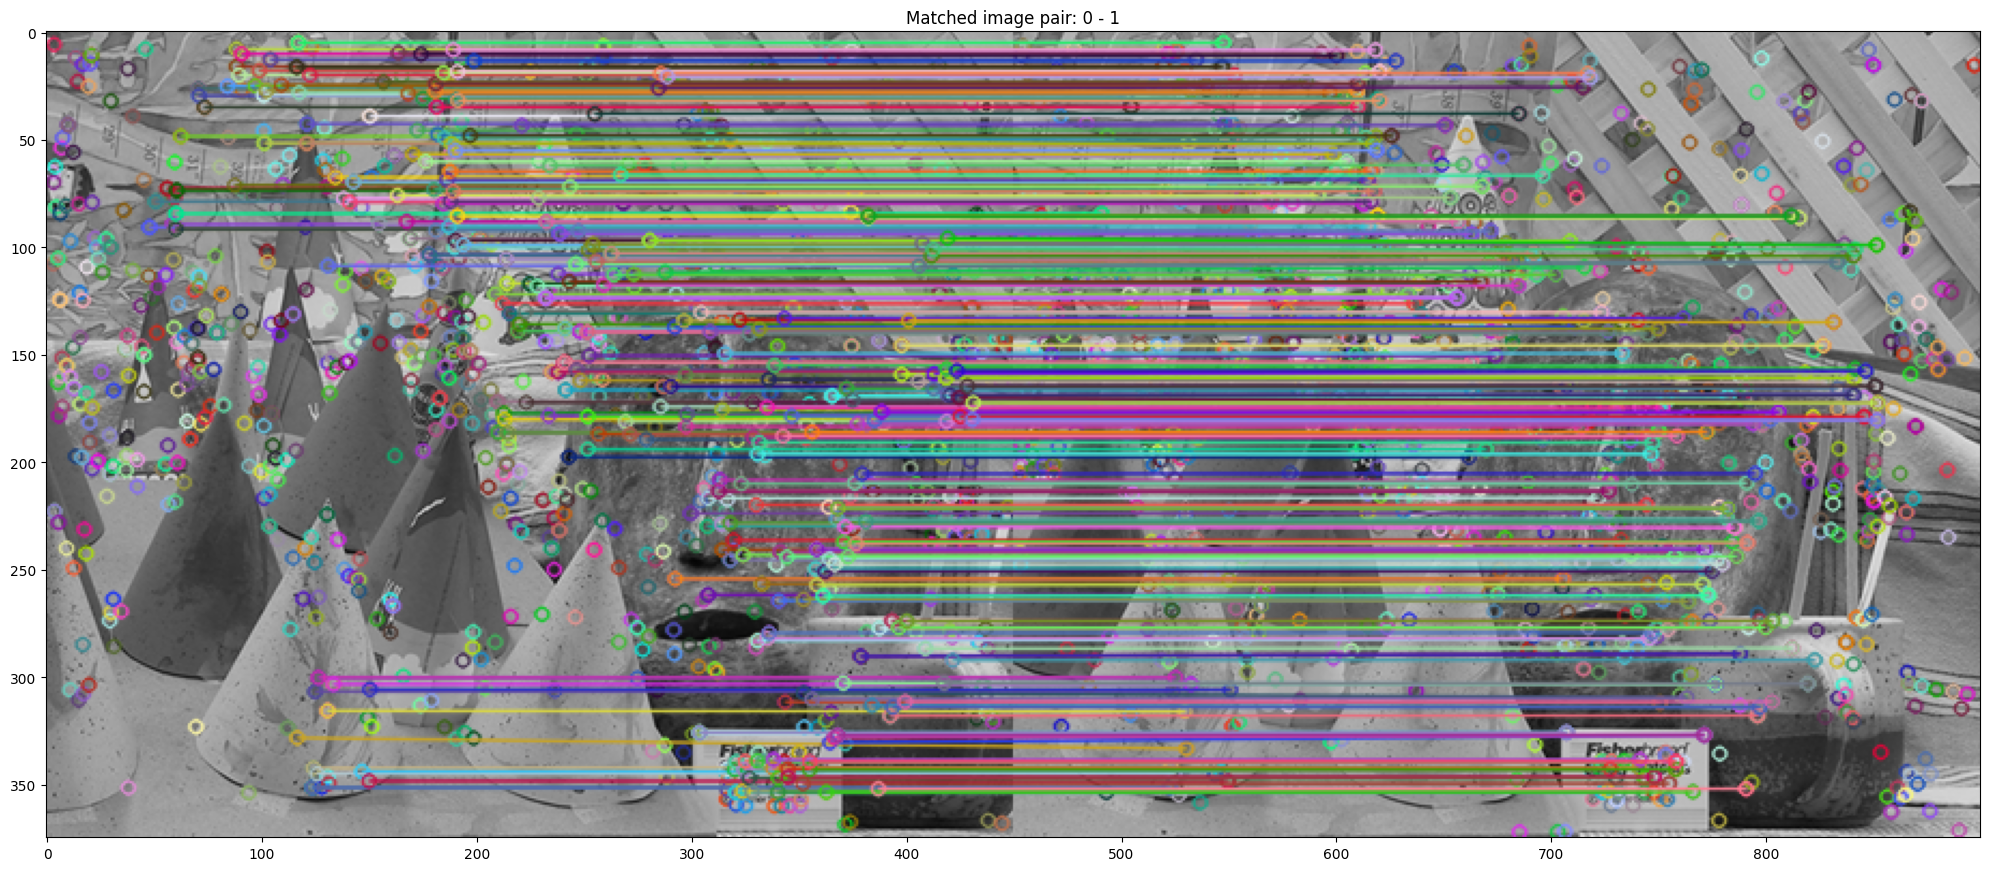

In [3]:
detector = vision.features.SIFT(num_features=2000)
pruner = vision.features.GMSPruner()
detection = vision.features.Detection(images, detector_type=detector, sampler=None, pruner=pruner)
key_points = detection.extract_keypoints()
match_indices = [(0, 1)]
for match_index in match_indices:
    src, trg = match_index[0], match_index[1]
    matches = detection.detect_matches(src, trg)
    keypoints1 = [cv2.KeyPoint(key_point.location[0], key_point.location[1], size=1) for key_point in key_points[src]]
    keypoints2 = [cv2.KeyPoint(key_point.location[0], key_point.location[1], size=1) for key_point in key_points[trg]]
    cv_matches = [cv2.DMatch(match.sourceIndex, match.targetIndex, 0) for match in matches]
    img_src = cv2.cvtColor(np.array(images[src]), cv2.COLOR_RGB2GRAY)
    img_trg = cv2.cvtColor(np.array(images[trg]), cv2.COLOR_RGB2GRAY)
    matched_img = cv2.drawMatches(img_src, keypoints1, img_trg, keypoints2, cv_matches, None)

    plt.figure(figsize=(20,10))
    plt.imshow(matched_img, cmap='gray')
    plt.title(f'Matched image pair: {src} - {trg}')
    plt.tight_layout()
    plt.show()